# 데이터 불러오기

In [2]:
import os
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# import warnings
# warnings.filterwarnings("ignore")

import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

from tqdm.auto import tqdm
from IPython.display import display

base_path = './'
data_path = os.path.join(base_path, 'data/')
books = pd.read_csv(data_path+'books.csv')

# 기초 정보

In [3]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149570 entries, 0 to 149569
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   isbn                 149570 non-null  object 
 1   book_title           149570 non-null  object 
 2   book_author          149569 non-null  object 
 3   year_of_publication  149570 non-null  float64
 4   publisher            149570 non-null  object 
 5   img_url              149570 non-null  object 
 6   language             82343 non-null   object 
 7   category             80719 non-null   object 
 8   summary              82343 non-null   object 
 9   img_path             149570 non-null  object 
dtypes: float64(1), object(9)
memory usage: 11.4+ MB


In [4]:
books.head(5)

,isbn,book_title,book_author,year_of_publication,publisher,img_url,language,category,summary,img_path
0,0002005018,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,en,['Actresses'],"In a small town in Canada, Clara Callan reluct...",images/0002005018.01.THUMBZZZ.jpg
1,0060973129,Decision in Normandy,Carlo D'Este,1991.0,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,en,['1940-1949'],"Here, for the first time in paperback, is an o...",images/0060973129.01.THUMBZZZ.jpg
2,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999.0,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,en,['Medical'],"Describes the great flu epidemic of 1918, an o...",images/0374157065.01.THUMBZZZ.jpg
3,0399135782,The Kitchen God's Wife,Amy Tan,1991.0,Putnam Pub Group,http://images.amazon.com/images/P/0399135782.0...,en,['Fiction'],A Chinese immigrant who is convinced she is dy...,images/0399135782.01.THUMBZZZ.jpg
4,0425176428,What If?: The World's Foremost Military Histor...,Robert Cowley,2000.0,Berkley Publishing Group,http://images.amazon.com/images/P/0425176428.0...,en,['History'],"Essays by respected military historians, inclu...",images/0425176428.01.THUMBZZZ.jpg


# 결측치 관측

In [5]:
# 1. 결측치 개수 계산
missing_count = books.isnull().sum()

# 2. 결측치 비율 계산 ((결측치 수 / 전체 데이터 수) * 100)
missing_ratio = (missing_count / len(books)) * 100

# 3. 데이터프레임으로 정리
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Ratio (%)': missing_ratio.round(2)  # 소수점 둘째자리까지 반올림
})

# 4. 결측치가 많은 순서대로 정렬 (내림차순)
missing_df = missing_df.sort_values(by='Missing Count', ascending=False)

# 5. 텍스트 결과 출력
print("=== books 데이터 컬럼별 결측치 현황 ===")
print(missing_df)
print("\n")


=== books 데이터 컬럼별 결측치 현황 ===
                     Missing Count  Ratio (%)
category                     68851      46.03
language                     67227      44.95
summary                      67227      44.95
book_author                      1       0.00
book_title                       0       0.00
isbn                             0       0.00
img_url                          0       0.00
publisher                        0       0.00
year_of_publication              0       0.00
img_path                         0       0.00




## 결측치 상호관계 파악

language & summary

In [6]:
lang_missing_mask = books['language'].isnull()
sum_missing_mask = books['summary'].isnull()

# 2. 교차표 생성
check_matrix = pd.crosstab(lang_missing_mask, sum_missing_mask, 
                           rownames=['Language Missing?'], 
                           colnames=['Summary Missing?'])

print("=== 결측치 관계 교차표 ===")
print(check_matrix)
print("-" * 30)

# 3. 논리적 검증 및 결론 도출
# 두 마스크가 완전히 똑같은지 확인
are_totally_same = (lang_missing_mask == sum_missing_mask).all()

if are_totally_same:
    print(f"✅ 결론: 두 컬럼은 100% 동일한 위치에서 결측치가 발생했습니다.")
    print(f"   (Language가 비어있으면 Summary도 무조건 비어있습니다.)")
else:
    # 만약 다르다면 차이 나는 개수 계산
    only_lang = (lang_missing_mask & ~sum_missing_mask).sum()
    only_sum = (~lang_missing_mask & sum_missing_mask).sum()
    print(f"❌ 결론: 두 컬럼의 결측 위치가 완벽히 일치하지 않습니다.")
    print(f"   - Language만 비어있는 경우: {only_lang}개")
    print(f"   - Summary만 비어있는 경우: {only_sum}개")

=== 결측치 관계 교차표 ===
Summary Missing?   False  True 
Language Missing?              
False              82343      0
True                   0  67227
------------------------------
✅ 결론: 두 컬럼은 100% 동일한 위치에서 결측치가 발생했습니다.
   (Language가 비어있으면 Summary도 무조건 비어있습니다.)


category & summary(language)

In [7]:
# 1. 마스크 생성
sum_missing = books['summary'].isnull()
cat_missing = books['category'].isnull()

# 2. 교차표(Crosstab) 생성
cross_tab = pd.crosstab(sum_missing, cat_missing, 
                        rownames=['Summary Missing?'], 
                        colnames=['Category Missing?'])

print("=== Summary와 Category 결측 관계표 ===")
print(cross_tab)
print("-" * 40)

# 3. 가설 검증: Summary가 Null이면 -> Category도 Null인가?
# Summary가 결측인데(True), Category는 결측이 아닌(False) 경우가 0이어야 함
sum_null_but_cat_exist = books[sum_missing & ~cat_missing]
count_exception = len(sum_null_but_cat_exist)

if count_exception == 0:
    print("✅ 확인됨: Summary가 비어있으면, Category는 100% 비어있습니다.")
    print(f"   (Summary 결측치 {sum_missing.sum()}개는 모두 Category 결측치에 포함됩니다.)")
else:
    print(f"❌ 확인됨: Summary가 비어있지만 Category는 존재하는 데이터가 {count_exception}개 있습니다.")

print("-" * 40)

# 4. 상세 분포 계산
both_missing = (sum_missing & cat_missing).sum()
only_cat_missing = (~sum_missing & cat_missing).sum() # Summary는 있는데 Category만 빈 경우
total_len = len(books)

print("=== 상세 결측 분포 ===")
print(f"1. 둘 다 비어있는 경우: {both_missing}개 ({both_missing/total_len*100:.2f}%)")
print(f"2. Summary는 있고 Category만 비어있는 경우: {only_cat_missing}개 ({only_cat_missing/total_len*100:.2f}%)")
print(f"   (참고: Category 총 결측 {cat_missing.sum()}개 = {both_missing} + {only_cat_missing})")

=== Summary와 Category 결측 관계표 ===
Category Missing?  False  True 
Summary Missing?               
False              80719   1624
True                   0  67227
----------------------------------------
✅ 확인됨: Summary가 비어있으면, Category는 100% 비어있습니다.
   (Summary 결측치 67227개는 모두 Category 결측치에 포함됩니다.)
----------------------------------------
=== 상세 결측 분포 ===
1. 둘 다 비어있는 경우: 67227개 (44.95%)
2. Summary는 있고 Category만 비어있는 경우: 1624개 (1.09%)
   (참고: Category 총 결측 68851개 = 67227 + 1624)


# 중복값 관측

In [8]:
# 책 제목이 같으면서 isbn이 다른 도서가 있는 것 같습니다.
result = books[books.duplicated(['book_title'], keep= 'first') == True]
print(len(result))

14134


# 출판년도 분석


=== 가장 책이 많이 출판된 연도 Top 5 ===
year_of_publication
2002.0    11669
2001.0    11020
1999.0    10480
2000.0    10391
2003.0     9430
Name: count, dtype: int64


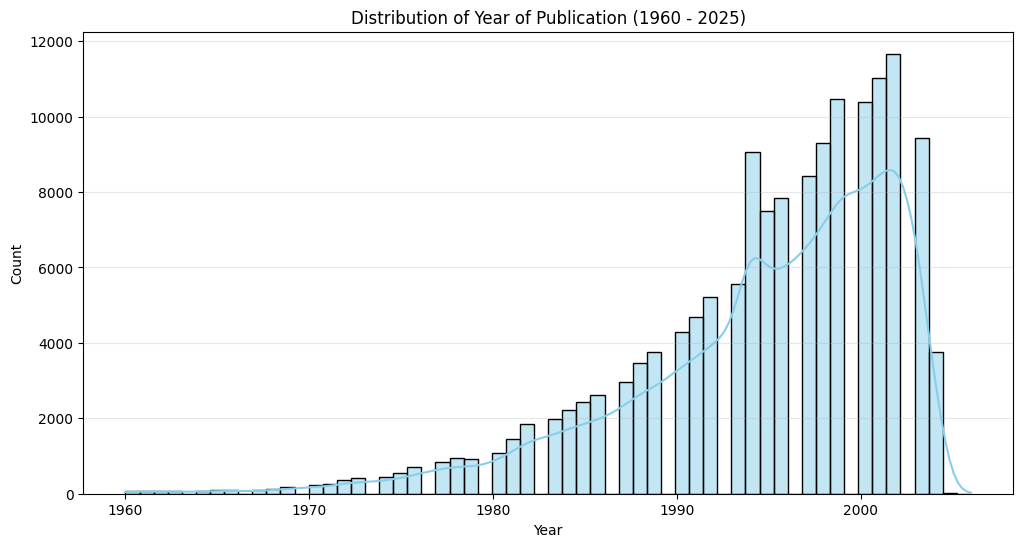

In [9]:
# 1. 데이터 정제: 수치형 변환
# 'DK Publishing Inc' 같은 오타가 섞여있을 수 있어 errors='coerce'로 처리(문자는 NaN이 됨)
books['year_of_publication'] = pd.to_numeric(books['year_of_publication'], errors='coerce')

# 2. 데이터 상태 점검 (0년 및 결측치 확인)
zero_count = (books['year_of_publication'] == 0).sum()
nan_count = books['year_of_publication'].isnull().sum()
total = len(books)

# 3. 유효한 연도 필터링
# 역사적인 책을 고려해 1300년~2025년 사이를 유효 범위로 가정
# (이 데이터셋은 2004년경 수집되었으므로 2025년 이후는 오기입일 확률이 높음)
valid_books = books[(books['year_of_publication'] > 1300) & (books['year_of_publication'] <= 2025)]
invalid_books = books[(books['year_of_publication'] > 2025) | ((books['year_of_publication'] <= 1300) & (books['year_of_publication'] != 0))]

# 4. 시각화 (1960년 이후 집중 확인)
# 1900년 이전 데이터는 매우 적으므로, 분포를 잘 보기 위해 1960년 이후로 잘라서 시각화
plt.figure(figsize=(12, 6))
subset_for_plot = valid_books[valid_books['year_of_publication'] >= 1960]

sns.histplot(data=subset_for_plot, x='year_of_publication', bins=60, kde=True, color='skyblue')
plt.title('Distribution of Year of Publication (1960 - 2025)')
plt.xlabel('Year')
plt.ylabel('Count')

# 상위 5개 연도 텍스트 표시
top_years = valid_books['year_of_publication'].value_counts().head(5)
print("\n=== 가장 책이 많이 출판된 연도 Top 5 ===")
print(top_years)

plt.grid(axis='y', alpha=0.3)
plt.show()

# 카테고리 분석

=== 카테고리 분석 요약 ===
총 고유 카테고리 수: 4292개
상위 1위 카테고리: Unknown (68851개)

=== 상위 20개 카테고리 분포 ===
                           Count  Ratio (%)
category_clean                             
Unknown                    68851      46.03
Fiction                    32956      22.03
Juvenile Fiction            5804       3.88
Biography & Autobiography   3320       2.22
History                     1925       1.29
Religion                    1818       1.22
Juvenile Nonfiction         1417       0.95
Social Science              1231       0.82
Humor                       1161       0.78
Body, Mind & Spirit         1109       0.74
Business & Economics        1070       0.72
Cooking                     1025       0.69
Health & Fitness             968       0.65
Family & Relationships       959       0.64
Computers                    730       0.49
Travel                       651       0.44
Self-Help                    640       0.43
Psychology                   635       0.42
Poetry                       

/tmp/ipykernel_424588/3094744689.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20.values, y=top_20.index, palette='viridis')


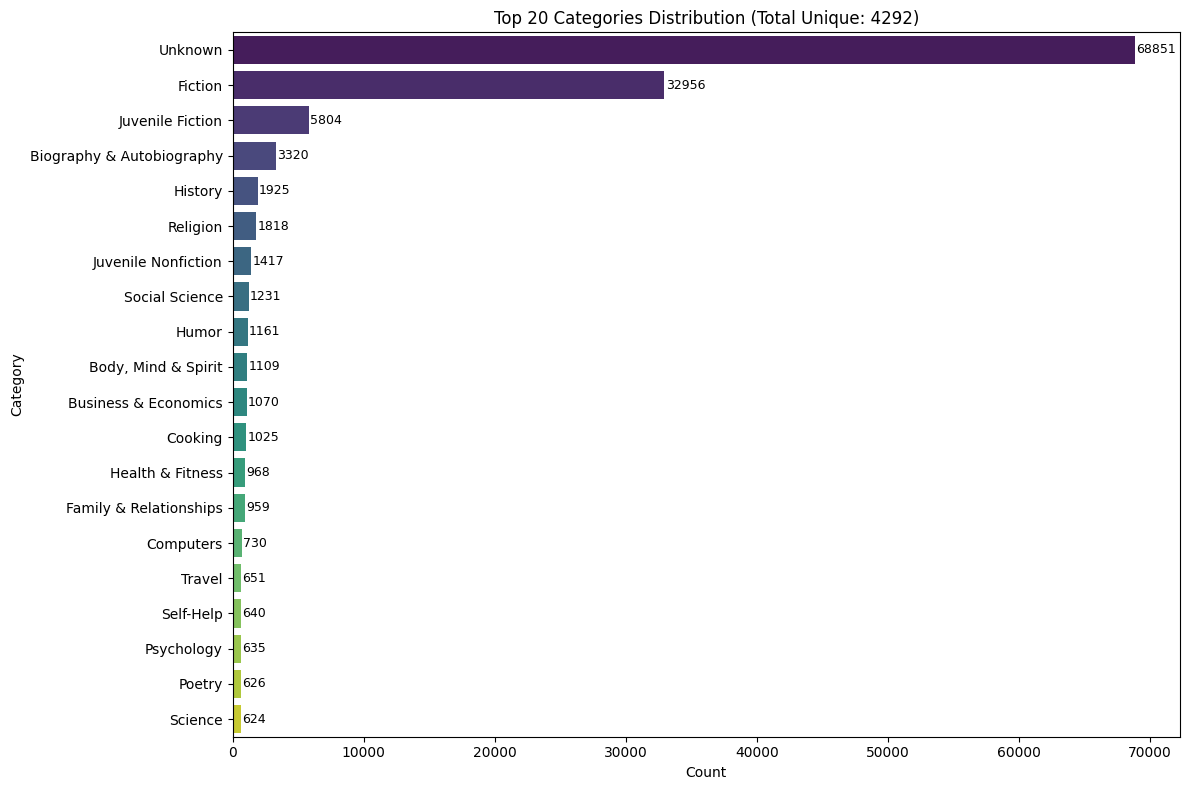


[참고] 책이 딱 1권만 있는 희소 카테고리 수: 2709개
      (전체 카테고리의 63.1%)


In [10]:
import re

# 1. 카테고리 데이터 정제 함수
def clean_category(text):
    if pd.isna(text):
        return "Unknown" # 결측치는 Unknown으로 처리 (혹은 제외 가능)
    
    # 정규표현식으로 대괄호[], 따옴표'', "" 제거
    clean_text = re.sub(r"[\[\]'\"']", "", str(text))
    return clean_text.strip()

# 2. 정제 적용
books['category_clean'] = books['category'].apply(clean_category)

# 3. 분포 계산
# Unknown(결측치)을 제외하고 분석하고 싶다면 아래 줄 주석 해제
# valid_categories = books[books['category_clean'] != 'Unknown']['category_clean']
valid_categories = books['category_clean']

cat_counts = valid_categories.value_counts()
total_unique = len(cat_counts)

# 4. 상위 20개 추출
top_20 = cat_counts.head(20)

# 비율 계산
top_20_ratio = (top_20 / len(books) * 100).round(2)

print(f"=== 카테고리 분석 요약 ===")
print(f"총 고유 카테고리 수: {total_unique}개")
print(f"상위 1위 카테고리: {cat_counts.index[0]} ({cat_counts.iloc[0]}개)")
print("\n=== 상위 20개 카테고리 분포 ===")
print(pd.DataFrame({'Count': top_20, 'Ratio (%)': top_20_ratio}))

# 5. 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x=top_20.values, y=top_20.index, palette='viridis')
plt.title(f'Top 20 Categories Distribution (Total Unique: {total_unique})')
plt.xlabel('Count')
plt.ylabel('Category')

# 막대 옆에 수치 표시
for i, v in enumerate(top_20.values):
    plt.text(v + 100, i, f'{v}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 6. 롱테일(Long-tail) 확인: 데이터가 너무 희소하지 않은지?
single_count_cats = (cat_counts == 1).sum()
print(f"\n[참고] 책이 딱 1권만 있는 희소 카테고리 수: {single_count_cats}개")
print(f"      (전체 카테고리의 {single_count_cats/total_unique*100:.1f}%)")

# Publisher 분석


=== 상위 10개 출판사 분포 ===
                          Count  Ratio (%)
publisher                                 
Harlequin                  3005       2.01
Ballantine Books           2322       1.55
Pocket                     2274       1.52
Penguin Books              1943       1.30
Bantam Books               1938       1.30
Berkley Publishing Group   1754       1.17
Silhouette                 1684       1.13
Warner Books               1667       1.11
Scholastic                 1586       1.06
Simon & Schuster           1578       1.06


/tmp/ipykernel_424588/2028531887.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10_pub.values, y=top_10_pub.index, palette='mako')


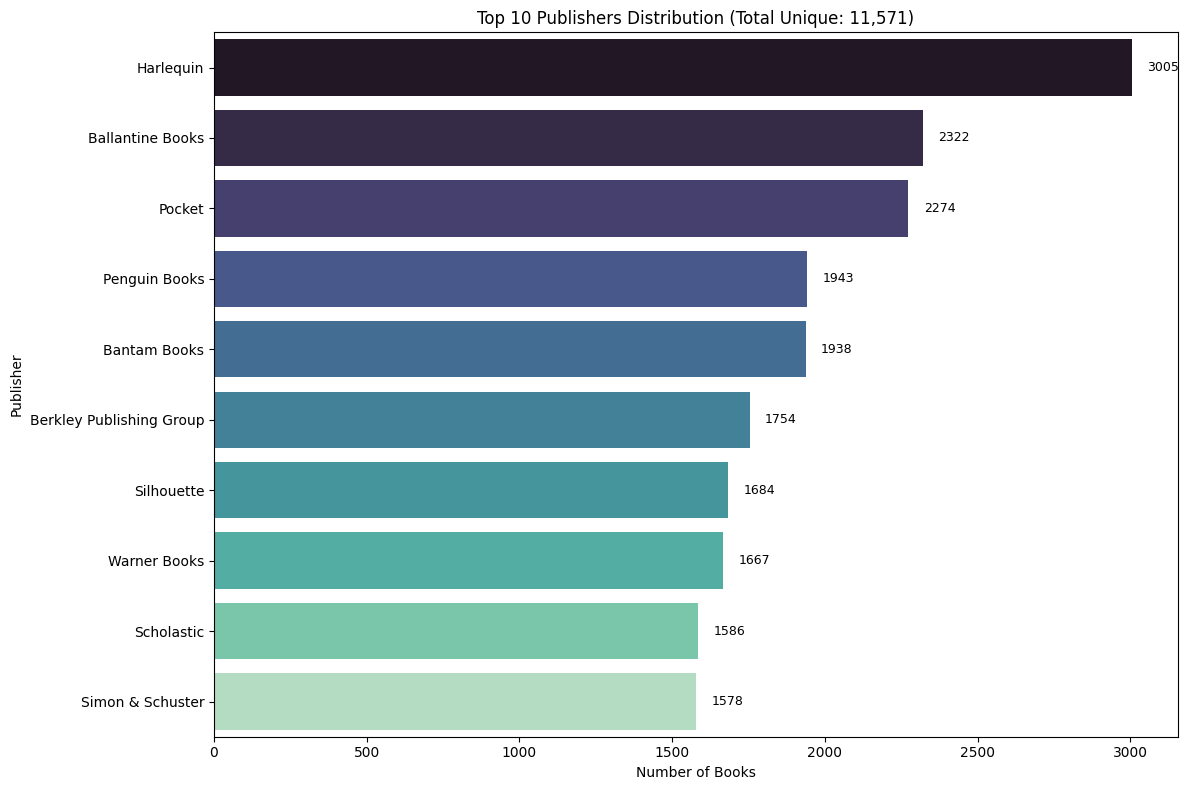


[참고] 책이 1권뿐인 희소 출판사: 6,295개
      (전체 출판사의 54.4%)


In [12]:
# 1. 결측치 확인 및 처리
# 결측치가 있다면 'Unknown'으로 채워서 카운트에 포함시킵니다.
missing_pub = books['publisher'].isnull().sum()
books['publisher'] = books['publisher'].fillna('Unknown')

# 2. 출판사별 책 개수 계산
# 공백 제거 등 간단한 전처리 후 카운트
pub_counts = books['publisher'].str.strip().value_counts()
total_books = len(books)
total_pubs = len(pub_counts)

# 3. 상위 20개 출판사 추출 및 비율 계산
top_10_pub = pub_counts.head(10)
top_10_df = pd.DataFrame({
    'Count': top_10_pub,
    'Ratio (%)': (top_10_pub / total_books * 100).round(2)
})

print("\n=== 상위 10개 출판사 분포 ===")
print(top_10_df)

# 4. 시각화 (Bar Chart)
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=top_10_pub.values, y=top_10_pub.index, palette='mako')

plt.title(f'Top 10 Publishers Distribution (Total Unique: {total_pubs:,})')
plt.xlabel('Number of Books')
plt.ylabel('Publisher')

# 막대 옆에 수치 표시
for i, v in enumerate(top_10_pub.values):
    ax.text(v + 50, i, f'{v}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 5. 데이터 파편화(Long-tail) 확인
# 책을 딱 1권만 낸 출판사가 얼마나 많은지 확인
single_book_pubs = (pub_counts == 1).sum()
print(f"\n[참고] 책이 1권뿐인 희소 출판사: {single_book_pubs:,}개")
print(f"      (전체 출판사의 {single_book_pubs/total_pubs*100:.1f}%)")